In [ ]:
import numpy as np
import pandas as pd


In [2]:
df=pd.read_csv('/content/Churn_Modelling.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/Churn_Modelling.csv'

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

NameError: name 'df' is not defined

In [4]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

NameError: name 'df' is not defined

In [5]:
df.head()

NameError: name 'df' is not defined

In [164]:
X=df.drop(columns=['Exited'])

In [165]:
Y=df['Exited'].values

In [166]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [167]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [168]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [169]:
X_train_scaled

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [170]:
X_test_scaled

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [6]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


ModuleNotFoundError: No module named 'tensorflow'

In [172]:
model=Sequential()

In [173]:
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [174]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [175]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [176]:
history = model.fit(X_train_scaled,y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7581 - loss: 0.5771 - val_accuracy: 0.7969 - val_loss: 0.5152
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.4931 - val_accuracy: 0.7969 - val_loss: 0.4692
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8069 - loss: 0.4516 - val_accuracy: 0.8069 - val_loss: 0.4434
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8147 - loss: 0.4299 - val_accuracy: 0.8125 - val_loss: 0.4320
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8203 - loss: 0.4189 - val_accuracy: 0.8150 - val_loss: 0.4239
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8230 - loss: 0.4107 - val_accuracy: 0.8150 - val_loss: 0.4178
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8255 - loss: 0.4045 - val_accuracy: 0.8219 - val_loss: 0.4108
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8295 - loss: 0.3977 - val_accu

In [177]:
model.layers[0].get_weights()



[array([[-1.09790631e-01, -8.94971415e-02, -2.31340225e-03,
         -7.02785552e-02, -7.57858753e-02, -2.92770386e-01,
          7.02690005e-01, -1.12298630e-01,  1.86711401e-02,
          1.24418493e-02,  5.77652343e-02],
        [-7.10665941e-01, -3.13993067e-01,  8.42561185e-01,
          8.12186122e-01,  9.17015523e-02, -4.10856038e-01,
         -1.65518135e-01,  5.66260278e-01, -3.86683047e-01,
         -2.61800647e-01,  3.84641290e-02],
        [ 2.72837132e-01, -4.51946020e-01, -2.97087152e-02,
          2.53243059e-01,  1.64497942e-01,  1.29609252e-03,
         -3.56347889e-01,  1.25360236e-01, -1.23802088e-01,
          4.00662988e-01, -1.72360748e-01],
        [ 1.31297231e-01, -6.68263555e-01, -8.48859400e-02,
         -7.73596168e-01, -2.96720475e-01, -9.63599265e-01,
         -3.35384250e-01, -3.97756994e-01, -6.75275207e-01,
         -4.80627507e-01, -1.53786942e-01],
        [-1.42912418e-01,  4.99082431e-02, -6.24579906e-01,
         -1.55482396e-01,  1.38465166e+00, -

In [178]:
model.layers[1].get_weights()

[array([[-1.0044986 ,  0.7730733 , -0.5316545 , -0.39802948, -0.47937393,
          0.54001236,  0.28251895, -0.2481166 , -0.05889637,  0.37246308,
          0.38029835],
        [-0.01868599,  0.24816965,  0.61441225,  0.74492705,  0.26945704,
          0.1648901 ,  0.31881368,  0.03184431,  0.45234   ,  0.43264592,
         -0.32214448],
        [ 0.1582334 , -0.06488175,  0.16334315, -0.45947927,  0.17972083,
         -0.4822536 , -0.53051114, -0.6890457 , -0.3804248 , -0.25048777,
          0.41126367],
        [-0.70690805, -0.05797411, -0.05196876, -0.4023838 , -0.23877105,
         -0.5817454 , -0.4339298 ,  0.36773798,  0.1459459 ,  0.73327404,
          0.6547882 ],
        [ 1.2872679 , -0.17623523, -0.09030809,  0.1604909 , -0.6013248 ,
          0.20140025, -0.02159878,  0.01475158, -0.24497688, -0.32121462,
         -0.08924282],
        [-1.0012746 , -0.17897767,  0.42881566,  0.5528481 ,  0.43444687,
          0.45670548,  0.5752857 , -0.33734107,  0.48947743,  0.1587242

In [179]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [180]:
y_pred=np.where(y_log>0.5,1,0)

In [181]:

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8575

In [182]:
import matplotlib.pyplot as plt


In [183]:
history.history

{'accuracy': [0.7581250071525574,
  0.7957812547683716,
  0.8068749904632568,
  0.8146874904632568,
  0.8203125,
  0.8229687213897705,
  0.8254687786102295,
  0.8295312523841858,
  0.8303124904632568,
  0.8326562643051147,
  0.8409374952316284,
  0.8490625023841858,
  0.8543750047683716,
  0.8579687476158142,
  0.8590624928474426,
  0.8598437309265137,
  0.858593761920929,
  0.8600000143051147,
  0.8614062666893005,
  0.8615624904632568,
  0.8614062666893005,
  0.86328125,
  0.8607812523841858,
  0.8617187738418579,
  0.8639062643051147,
  0.8629687428474426,
  0.8606250286102295,
  0.8623437285423279,
  0.8623437285423279,
  0.8623437285423279,
  0.8623437285423279,
  0.862500011920929,
  0.86328125,
  0.8628125190734863,
  0.86328125,
  0.8620312213897705,
  0.864062488079071,
  0.8618749976158142,
  0.8639062643051147,
  0.8628125190734863,
  0.8618749976158142,
  0.8657812476158142,
  0.864062488079071,
  0.8650000095367432,
  0.8634374737739563,
  0.8631250262260437,
  0.864687502

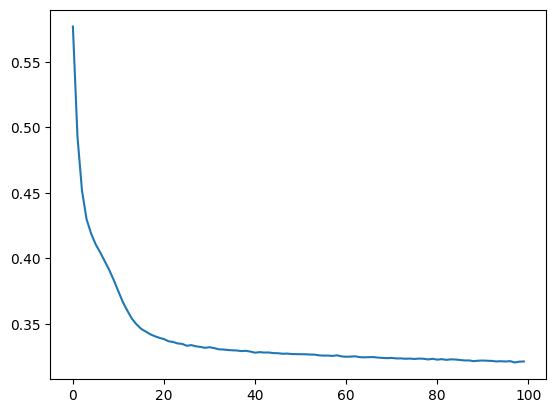

In [184]:
plt.plot(history.history['loss'])

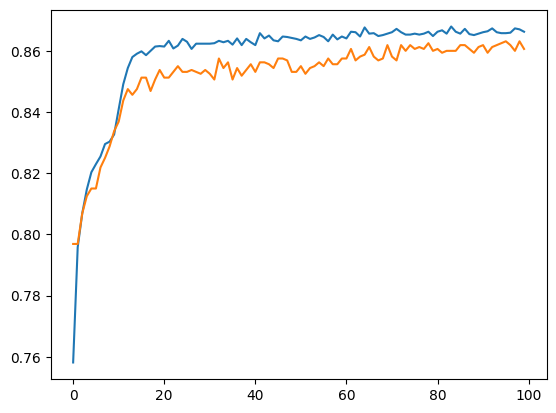

In [185]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])